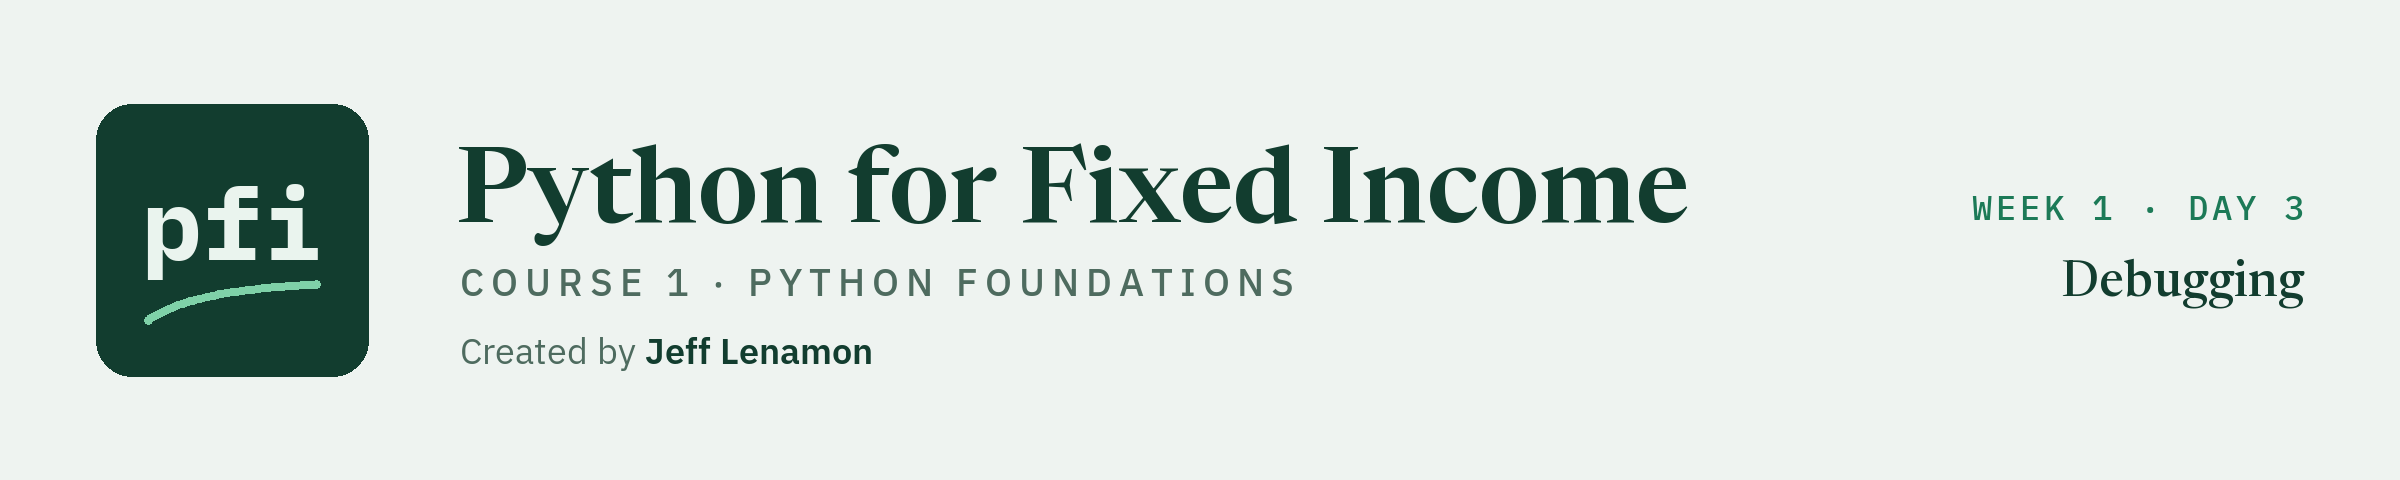

# Debugging

Week 1. Finding and fixing the mistakes in code, using broken calculations from a bond desk.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week1/day3/03_debugging.ipynb)

Everyone who writes code makes mistakes, on the first day and after twenty years. A mistake in code is called a **bug**, and finding and fixing it is called **debugging**. Python helps: when it cannot run something, it stops and says what went wrong and where.

A new analyst has joined the credit desk and written some code for the desk's four bonds. Every piece of it has a bug. In this notebook we find and fix each one. The red error blocks you will see are there on purpose.

For every bug we follow the same four steps:

1. Run the code and let it fail.
2. Read what Python says, starting from the last line.
3. Work out the cause.
4. Fix it and run it again.

The four bonds are the ones from the earlier notebooks. The issuers are invented.

| Ticker | Coupon (%) | Maturity | Price | Rating | Face held |
| --- | --- | --- | --- | --- | --- |
| QVNE | 5.25 | 2033 | 98.50 | BBB | 1,500,000 |
| DNMR | 6.125 | 2034 | 103.25 | BB+ | 500,000 |
| PLWK | 4.75 | 2031 | 95.00 | A- | 750,000 |
| HLVF | 7.50 | 2032 | 101.00 | B+ | 250,000 |

In [1]:
# the desk's data, as lists
ticker_list = ['QVNE', 'DNMR', 'PLWK', 'HLVF']
coupon_list = [5.25, 6.125, 4.75, 7.5]
price_list = [98.5, 103.25, 95.0, 101.0]
face_list = [1500000, 500000, 750000, 250000]

## 3.1 Reading a Traceback

Q. The analyst wants to print the coupon of QVNE. Run the code.

In [2]:
# store the coupon of QVNE
coupon = 5.25
# print it
print('The coupon is', cupon)

NameError: name 'cupon' is not defined

The red block is called a **traceback**. It is Python's report of what went wrong. Read it from the bottom up.

* **The last line names the error.** Here it is a `NameError`, and the message says the name 'cupon' is not defined.
* **The arrow marks the line.** `---->` points at the line where Python stopped.
* **The top says which cell.** The number in `Cell In[...]` matches the number beside the cell.

The cause: the variable was stored as `coupon` and then spelled `cupon`. To Python those are two different names.

Ask three questions of every traceback: **what type of error, what does the message say, and which line.**

In [3]:
# store the coupon of QVNE
coupon = 5.25
# print it, with the name spelled correctly
print('The coupon is', coupon)

The coupon is 5.25


> STORY: On September 9, 1947, engineers working on Harvard's Mark II computer found a moth inside the machine. Someone taped it into the log book with a note calling it the first actual case of a bug being found. The joke only works because engineers already called faults "bugs": Thomas Edison used the word that way in a letter in 1878. The log book, moth included, is in the Smithsonian's National Museum of American History. The story is often told about Grace Hopper, who worked on the Mark II, but the museum notes the log book was probably not hers.
>
> Source: https://daily.jstor.org/the-bug-in-the-computer-bug-story/ and the museum's object record at https://americanhistory.si.edu/collections/object/nmah_334663

## 3.2 Syntax Errors

**Syntax** is the grammar of the language. A syntax error means Python could not even read the code, so nothing in the cell runs at all.

Q. The analyst wants to print every ticker. Run the code.

In [4]:
for ticker in ticker_list
    print(ticker)

SyntaxError: expected ':' (627221158.py, line 1)

* A `SyntaxError`. The message says a colon was expected, and a small `^` points at the exact spot.
* A `for` line must end with a colon. So must `if`, `elif`, `else`, `while`, and `def`.

In [5]:
# the colon at the end of the for line was missing
for ticker in ticker_list:
    print(ticker)

QVNE
DNMR
PLWK
HLVF


Q. The analyst wants to check whether QVNE trades at par. Run the code.

In [6]:
price = 98.5

if price = 100:
    print('QVNE trades at par')
else:
    print('QVNE does not trade at par')

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (4219805903.py, line 3)

* Another `SyntaxError`, and this time Python suggests the fix.
* A single `=` stores a value. A double `==` asks whether two values are equal. An `if` needs a question, so it needs `==`.

In [7]:
price = 98.5

# == compares, = stores
if price == 100:
    print('QVNE trades at par')
else:
    print('QVNE does not trade at par')

QVNE does not trade at par


Q. The analyst wants to add a fifth coupon to the list. Run the code.

In [8]:
new_coupon_list = [5.25, 6.125, 4.75, 7.5, 6.0
print(new_coupon_list)

SyntaxError: '[' was never closed (424841642.py, line 1)

* The message says the `[` was never closed. Every opening bracket, parenthesis, and quote needs its partner.
* Python often notices a missing bracket only on the *next* line. If the line with the arrow looks fine, look at the line above it.

In [9]:
# the closing bracket was missing
new_coupon_list = [5.25, 6.125, 4.75, 7.5, 6.0]
print(new_coupon_list)

[5.25, 6.125, 4.75, 7.5, 6.0]


Q. The analyst wants to print each price. Run the code.

In [10]:
for price in price_list:
print(price)

IndentationError: expected an indented block after 'for' statement on line 1 (2214392936.py, line 2)

* An `IndentationError`. The line after a colon must be indented, because the indentation is how Python knows what belongs inside the loop.

In [11]:
# the line inside the loop must be indented
for price in price_list:
    print(price)

98.5
103.25
95.0
101.0


## 3.3 Name and Type Errors

From here on the code is valid Python, so it starts running. The error appears only when Python reaches the line it cannot carry out.

Q. The analyst wants to store QVNE as a dictionary. Run the code.

In [12]:
bond = {Ticker: 'QVNE', 'Coupon': 5.25, 'Price': 98.5}
print(bond)

NameError: name 'Ticker' is not defined

* A `NameError`: the name 'Ticker' is not defined.
* Without quotes, Python reads `Ticker` as a variable name and goes looking for a variable that does not exist. A dictionary key that is text needs quotes.

In [13]:
# the key 'Ticker' needs quotes, like the other keys
bond = {'Ticker': 'QVNE', 'Coupon': 5.25, 'Price': 98.5}
print(bond)

{'Ticker': 'QVNE', 'Coupon': 5.25, 'Price': 98.5}


Q. The analyst wants to print a one-line description of QVNE. Run the code.

In [14]:
description = 'QVNE ' + 5.25 + '% of ' + 2033
print(description)

TypeError: can only concatenate str (not "float") to str

* A `TypeError`: Python can only join a string to another string.
* A type error means the operation is fine but the data type is wrong for it. The numbers have to be converted to strings first.

In [15]:
# str() converts each number to a string
description = 'QVNE ' + str(5.25) + '% of ' + str(2033)
print(description)

QVNE 5.25% of 2033


Q. The face held of QVNE arrives from a file as text. The analyst wants the annual coupon income. Run the code.

In [16]:
# the face amount as it arrived from the file
face = '1500000'
coupon = 5.25

income = face * coupon / 100
print('The annual coupon income is', income)

TypeError: can't multiply sequence by non-int of type 'float'

* Another `TypeError`, with a stranger message. Python is saying it cannot multiply text by a decimal number.
* The clue is in the first line of the cell: the face amount is in quotes, so it is a string. When a message makes no sense, check the type of each variable with `type()`.

In [17]:
# check the types
print(type(face))
print(type(coupon))

<class 'str'>
<class 'float'>


In [18]:
# convert the text to a number before using it
face = int('1500000')
coupon = 5.25

income = face * coupon / 100
print('The annual coupon income is', income)

The annual coupon income is 78750.0


## 3.4 Index and Key Errors

Q. The analyst wants to print the ticker of each of the four bonds. Run the code.

In [19]:
for i in range(1, 5):
    print(ticker_list[i])

DNMR
PLWK
HLVF


IndexError: list index out of range

* An `IndexError`: list index out of range. Notice that three tickers printed before the error. The code ran until it hit the problem.
* Notice also that QVNE is missing. The list has four items at indexes 0, 1, 2, and 3. `range(1, 5)` produces 1, 2, 3, and 4, so the loop skipped index 0 and then asked for index 4, which does not exist.
* Counting from 1 when Python counts from 0 is one of the most common bugs there is.

In [20]:
# range(4) produces 0, 1, 2, 3
for i in range(4):
    print(ticker_list[i])

QVNE
DNMR
PLWK
HLVF


* Better still, loop over the list itself. With no index, there is nothing to get wrong.

In [21]:
for ticker in ticker_list:
    print(ticker)

QVNE
DNMR
PLWK
HLVF


Q. The analyst wants to print the coupon stored in the dictionary. Run the code.

In [22]:
bond = {'Ticker': 'QVNE', 'Coupon': 5.25, 'Price': 98.5}
print(bond['coupon'])

KeyError: 'coupon'

* A `KeyError`. The message is just the key that Python could not find: 'coupon'.
* The key in the dictionary is 'Coupon' with a capital C. Keys must match exactly, including upper and lower case.
* To see which keys a dictionary has, print `bond.keys()`.

In [23]:
# list the keys to see how they are spelled
print(bond.keys())
# use the key exactly as it is stored
print(bond['Coupon'])

dict_keys(['Ticker', 'Coupon', 'Price'])
5.25


## 3.5 Value and Zero Errors

Q. A broker sends the QVNE coupon as the text '5.25%'. The analyst wants it as a number. Run the code.

In [24]:
coupon_text = '5.25%'
coupon = float(coupon_text)
print(coupon)

ValueError: could not convert string to float: '5.25%'

* A `ValueError`: could not convert string to float.
* A value error means the type is right but the content is not. `float()` does accept a string, just not one with a percent sign in it.

In [25]:
coupon_text = '5.25%'
# replace the percent sign with nothing, then convert
coupon = float(coupon_text.replace('%', ''))
print(coupon)

5.25


Q. The analyst wants the current yield of each bond, which is the coupon divided by the price. Today's price feed has a problem: one price came through as 0. Run the code.

In [26]:
# today's prices, with a bad value for PLWK
feed_price_list = [98.5, 103.25, 0, 101.0]

for ticker, coupon, price in zip(ticker_list, coupon_list, feed_price_list):
    print(ticker, round(coupon / price * 100, 2))

QVNE 5.33
DNMR 5.93


ZeroDivisionError: float division by zero

* A `ZeroDivisionError`. Two bonds printed, then the loop reached PLWK and tried to divide by zero.
* This time the code is correct. The data is wrong. A bond does not have a price of 0, so the right fix is to deal with the bad value, not to change the formula.

In [27]:
for ticker, coupon, price in zip(ticker_list, coupon_list, feed_price_list):
    # skip any bond whose price is not a positive number, and say so
    if price <= 0:
        print(ticker, 'has a bad price:', price)
    else:
        print(ticker, round(coupon / price * 100, 2))

QVNE 5.33
DNMR 5.93
PLWK has a bad price: 0
HLVF 7.43


* The loop now finishes, and the bad price is reported instead of hidden.

## 3.6 Errors Inside Functions

When the failing line is inside a function, the traceback gets longer. It shows the line that called the function, and then the line inside the function that failed.

Q. The analyst wrote a function for current yield and used it in a loop. One price in the feed arrived as text. Run the code.

In [28]:
def current_yield(coupon, price):
    """
    Take the coupon (in percent) and the price (per 100 face)
    and return the current yield in percent.
    """
    return coupon / price * 100

In [29]:
# today's prices, with one that arrived as text
feed_price_list = [98.5, 103.25, '95.0', 101.0]

for ticker, coupon, price in zip(ticker_list, coupon_list, feed_price_list):
    print(ticker, round(current_yield(coupon, price), 2))

QVNE 5.33
DNMR 5.93


TypeError: unsupported operand type(s) for /: 'float' and 'str'

* There are now two arrows. Read from the bottom as always.
* **The last line** says it is a `TypeError`: Python cannot divide a float by a string.
* **The lower arrow** is inside the function, on the `return` line. That is where the division failed.
* **The upper arrow** is in our loop, on the line that called `current_yield`. That is how Python got there.

The function is fine. It was handed bad data. The lower arrow shows where the error happened, and the upper arrow shows where the bad value came from. The fix belongs in the loop.

In [30]:
for ticker, coupon, price in zip(ticker_list, coupon_list, feed_price_list):
    # convert every price to a number before passing it to the function
    price = float(price)
    print(ticker, round(current_yield(coupon, price), 2))

QVNE 5.33
DNMR 5.93
PLWK 5.0
HLVF 7.43


## 3.7 Bugs With No Error

The most dangerous bugs raise no error at all. The code runs, prints a number, and the number is wrong.

Q. The analyst wants the annual coupon income on the QVNE position: 1,500,000 face with a 5.25 percent coupon. Run the code.

In [31]:
face = 1500000
coupon = 5.25

income = face * coupon
print('The annual coupon income is', income)

The annual coupon income is 7875000.0


* No error. But 7.9 million dollars of coupon on a 1.5 million position cannot be right. A 5.25 percent coupon should pay a little over 5 percent of the face, so somewhere near 79,000.
* The coupon is in percent and was never divided by 100. Python had no way to know.
* The only defense is knowing roughly what the answer should be before you run the code.

In [32]:
face = 1500000
coupon = 5.25

# the coupon is in percent, so divide by 100
income = face * coupon / 100
print('The annual coupon income is', income)

The annual coupon income is 78750.0


Q. The analyst wants the simple average coupon of the four bonds. Run the code.

In [33]:
total = 0
for coupon in coupon_list:
    total = coupon

average_coupon = total / len(coupon_list)
print('The average coupon is', average_coupon)

The average coupon is 1.875


* No error again. But the coupons run from 4.75 to 7.5, so an average of 1.875 is impossible. An average must lie between the smallest and largest value.

When the cause is not obvious, add a `print()` inside the loop and watch the values change. This is the simplest debugging tool there is.

In [34]:
total = 0
for coupon in coupon_list:
    total = coupon
    # print the values on every pass through the loop
    print('coupon:', coupon, ' total so far:', total)

coupon: 5.25  total so far: 5.25
coupon: 6.125  total so far: 6.125
coupon: 4.75  total so far: 4.75
coupon: 7.5  total so far: 7.5


* The total is not growing. On each pass it is simply replaced by the latest coupon. The line should add the coupon to the total.

In [35]:
total = 0
for coupon in coupon_list:
    # add each coupon to the running total
    total = total + coupon

average_coupon = total / len(coupon_list)
print('The average coupon is', average_coupon)

The average coupon is 5.90625


* 5.90625, which sits between 4.75 and 7.5 as it should. Once the bug is fixed, take the extra `print()` out.

## 3.8 Handling Errors You Expect

Some errors are not bugs in our code. They come from data we do not control. When we can predict one, we can tell Python what to do when it happens, so that one bad value does not stop the whole run.

Q. Today's prices arrive as text, and one of them is 'n/a'. Convert each price to a number.

In [36]:
feed_text_list = ['98.5', '103.25', 'n/a', '101.0']

for ticker, text in zip(ticker_list, feed_text_list):
    price = float(text)
    print(ticker, 'is priced at', price)

QVNE is priced at 98.5
DNMR is priced at 103.25


ValueError: could not convert string to float: 'n/a'

* A `ValueError` on the third bond, and the fourth bond was never reached.

The `try` and `except` statements handle this:

```
try:
    code that might fail
except TheErrorType:
    what to do if it fails
```

In [37]:
for ticker, text in zip(ticker_list, feed_text_list):
    try:
        # try to convert the text to a number
        price = float(text)
        print(ticker, 'is priced at', price)
    except ValueError:
        # this runs only if float() raised a ValueError
        print(ticker, 'has a price that is not a number:', text)

QVNE is priced at 98.5
DNMR is priced at 103.25
PLWK has a price that is not a number: n/a
HLVF is priced at 101.0


* The loop finishes, and the bad value is reported by name.
* Always name the error you expect, here `ValueError`. A bare `except:` with no name would also swallow every other mistake in that block, including your own typos, and hide the very bugs this notebook is about.

**Excel side by side.** Excel has its own error values, and they line up closely with Python's. Excel's `IFERROR` plays the role of `try` and `except`.

| Excel shows | Python raises | Typical cause |
| --- | --- | --- |
| `#NAME?` | `NameError` | A misspelled name |
| `#VALUE!` | `TypeError` or `ValueError` | Text where a number was needed |
| `#DIV/0!` | `ZeroDivisionError` | Dividing by zero |
| `#REF!` | `IndexError` | Pointing at a cell or item that is not there |
| `#N/A` | `KeyError` | A lookup that found nothing |

The difference is that Excel puts the error in one cell and carries on. Python stops and tells you the line.

## Exercises

The analyst has also written code for a second desk, which holds three bonds. The issuers are invented.

| Ticker | Coupon (%) | Price | Rating | Score | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | 4.375 | 96.25 | A | 6 | 2,000,000 |
| OSMC | 5.00 | 100.00 | BBB- | 10 | 1,250,000 |
| CLDB | 8.25 | 104.50 | B | 15 | 500,000 |

Each exercise is a piece of code with one bug. Run it, read what happens, fix the code **in the same cell**, and run it again. Then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check`, loads the desk's data, and sets each answer to empty.

In [38]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the second desk's data
ticker_list = ['TRNW', 'OSMC', 'CLDB']
coupon_list = [4.375, 5.0, 8.25]
price_list = [96.25, 100.0, 104.5]
face_list = [2000000, 1250000, 500000]

# the answers start out empty
ex1_total_face = ...
ex2_current_yield = ...
ex3_tickers = ...
ex4_average_price = ...
ex5_ig_count = ...

### Exercise 1

Q. This code should total the face held. Fix it so that **ex1_total_face** holds the answer.

In [39]:
ex1_total_face = 0
for face in face_list
    ex1_total_face = ex1_total_face + face

print('The total face held is', ex1_total_face)

SyntaxError: expected ':' (1485305921.py, line 2)

In [40]:
check('Exercise 1', ex1_total_face, 3750000)

Exercise 1: not attempted yet


### Exercise 2

Q. This code should compute the current yield of TRNW, rounded to 2 decimals. Fix it so that **ex2_current_yield** holds the answer.

In [41]:
bond = {'Ticker': 'TRNW', 'Coupon': 4.375, 'Price': 96.25}

ex2_current_yield = round(bond['coupon'] / bond['price'] * 100, 2)
print('The current yield of TRNW is', ex2_current_yield)

KeyError: 'coupon'

In [42]:
check('Exercise 2', ex2_current_yield, 4.55)

Exercise 2: not attempted yet


### Exercise 3

Q. This code should build a list of all three tickers by index. Fix it so that **ex3_tickers** holds the answer.

In [43]:
ex3_tickers = []
for i in range(1, 4):
    ex3_tickers.append(ticker_list[i])

print(ex3_tickers)

IndexError: list index out of range

In [44]:
check('Exercise 3', ex3_tickers, ['TRNW', 'OSMC', 'CLDB'])

Exercise 3: not yet. You have ['OSMC', 'CLDB']


### Exercise 4

Q. The prices arrived from a file as text. This code should compute the simple average price. Fix it so that **ex4_average_price** holds the answer.

In [45]:
price_text_list = ['96.25', '100.0', '104.5']

total = 0
for text in price_text_list:
    total = total + text

ex4_average_price = total / len(price_text_list)
print('The average price is', ex4_average_price)

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [46]:
check('Exercise 4', ex4_average_price, 100.25)

Exercise 4: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for code that counts how many of the three bonds are investment grade. A bond is investment grade when its rating score is 10 or lower. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Before you run it, count the investment grade bonds yourself from the table. Then run the code. Does it agree with you?

In [47]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
score_list = [6, 10, 15]

ex5_ig_count = 0
for score in score_list:
    if score < 10:
        ex5_ig_count = ex5_ig_count + 1

print('Investment grade bonds:', ex5_ig_count)

Investment grade bonds: 1


Q. Find the bug and fix the code in the cell above, so that **ex5_ig_count** holds the right answer.

In [48]:
check('Exercise 5', ex5_ig_count, 2)

Exercise 5: not yet. You have 1
